# Plotting ROIs - Figure 6

Working with classes from `region_plotting.py`

In [ ]:
import matplotlib as mpl
import pandas as pd

from modules.region_plotting import RegionPlotter

In [2]:
mpl.rcParams.update({'pdf.fonttype': 42,
                     'ps.fonttype': 42,
                     'xtick.labelsize': 12,
                     'ytick.labelsize': 12,
                     'axes.labelsize': 12,
                     'font.size': 12
                    })

## Set parameters

In [3]:
# chip-seq
binsize = 200

rad21_wt = '/groups/gerlich/experiments/Experiments_006500/006575/bam_repo/RAD21/WT_G2/RAD21_WT_G2.chip.bw'
sor_wt = '/groups/gerlich/experiments/Experiments_006500/006575/bam_repo/Sororin/WT_G2/Sororin_WT_G2.chip.bw'
rad21_dwapl = '/groups/gerlich/experiments/Experiments_006500/006575/bam_repo/RAD21/dWAPL_G2/RAD21_dWAPL_G2.chip.bw'
sor_dwapl = '/groups/gerlich/experiments/Experiments_006500/006575/bam_repo/Sororin/dWAPL_G2/Sororin_dWAPL_G2.chip.bw'
rad21_dnipbl = '/groups/gerlich/experiments/Experiments_006500/006575/bam_repo/RAD21/dNIPBL_G2/RAD21_dNIPBL_G2.chip.bw'
sor_dnipbl = '/groups/gerlich/experiments/Experiments_006500/006575/bam_repo/Sororin/dNIPBL_G2/Sororin_dNIPBL_G2.chip.bw'
ctcf_wt = '/groups/gerlich/experiments/Experiments_006500/006575/bam_repo/CTCF/WT_G2/CTCF_WT_G2.chip.bw'

# boundaries
new_level_colors = {'high': 'k', 'med': '.6', 'low': 'w'}
edge_colors = {'high': None, 'med': None, 'low': 'k'}
hue = 'levelGroup'
boundaries_df = pd.read_parquet('/groups/gerlich/labinfo/Papers/2025_ReplChromConf/analysis/assets/tads_annot/boundaries.parquet')

# Set tick parameters
ticks_ctcf = [0, 2.8]
ticks_sor = [0, 1.8]
ticks_rad21 = [0, 2.5]

### Figure 6A - ChIP-Seq

In [4]:
# define region
region = ('chr2', 121_760_000, 121_940_000)

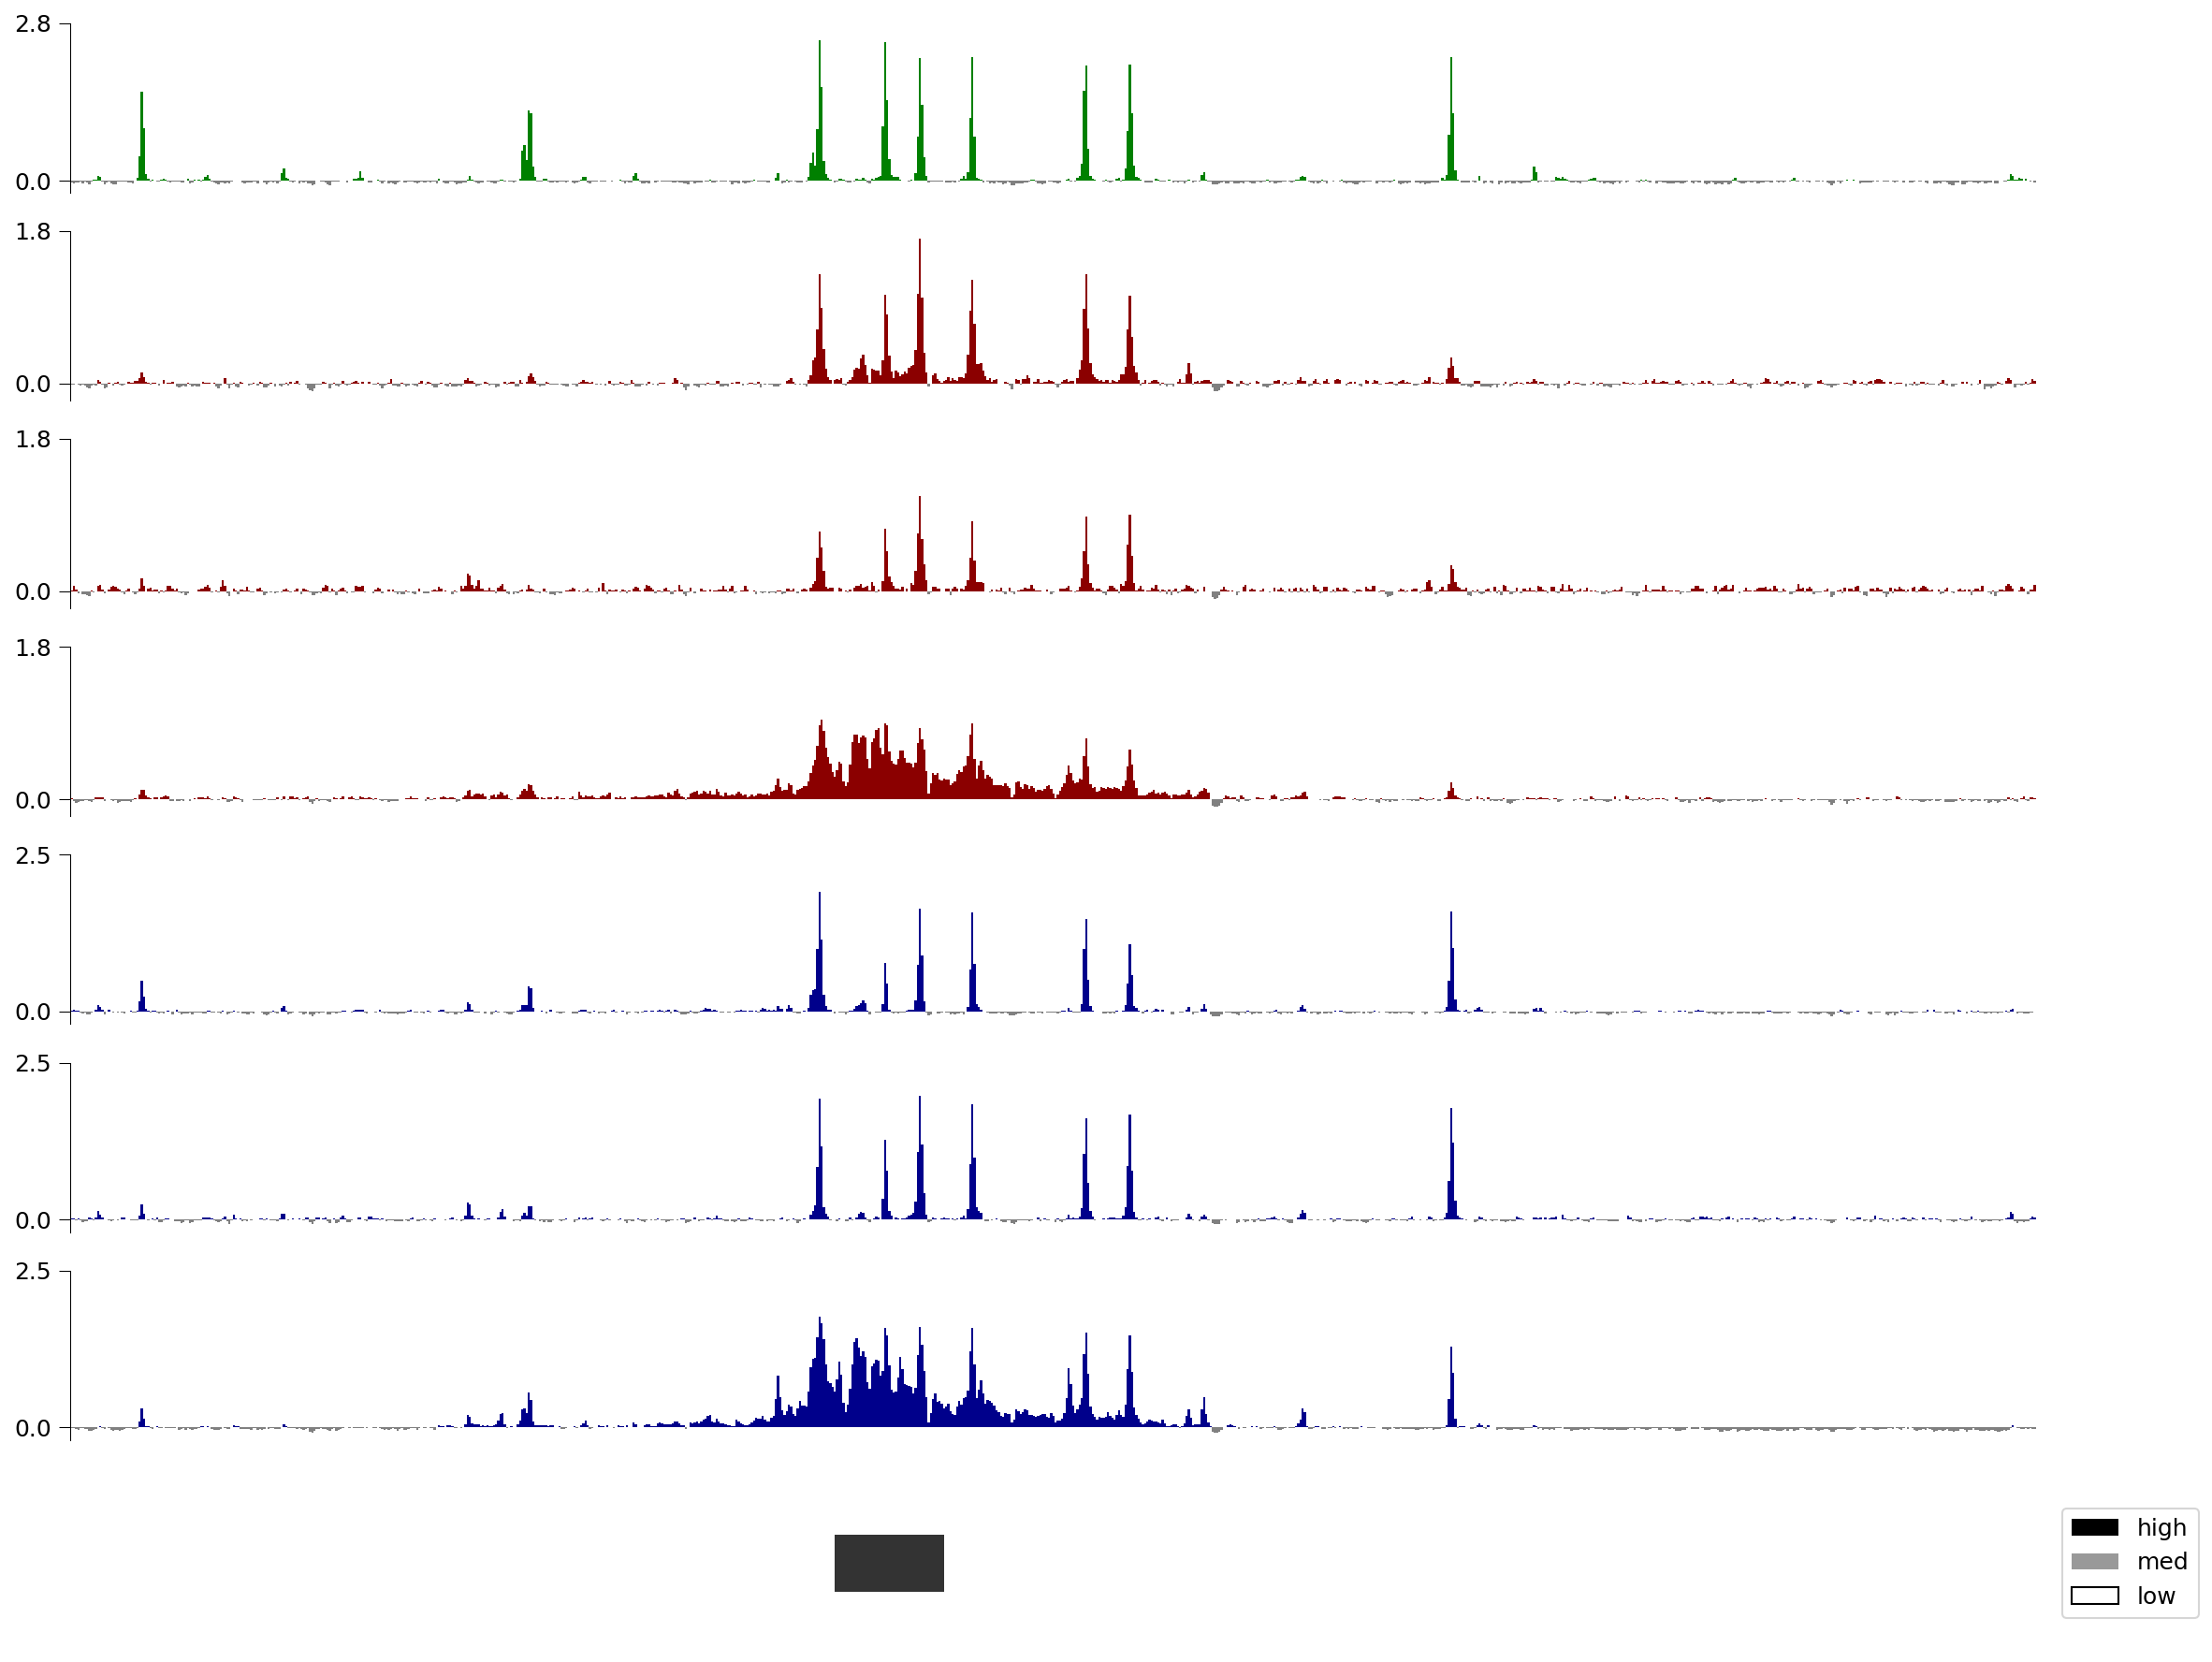

In [5]:
fig_plotter = RegionPlotter(*region)

fig_plotter.add_fill(ctcf_wt, binsize, -0.2, 2.8, 'grey', 'green', height=1, mean_subtract=True)
fig_plotter.add_fill(sor_wt, binsize, -0.2, 1.8, 'grey', 'darkred', height=1, mean_subtract=True)
fig_plotter.add_fill(sor_dnipbl, binsize, -0.2, 1.8, 'grey', 'darkred', height=1, mean_subtract=True)
fig_plotter.add_fill(sor_dwapl, binsize, -0.2, 1.8, 'grey', 'darkred', height=1, mean_subtract=True)
fig_plotter.add_fill(rad21_wt, binsize, -0.2, 2.5, 'grey', 'darkblue', height=1, mean_subtract=True)
fig_plotter.add_fill(rad21_dnipbl, binsize, -0.2, 2.5, 'grey', 'darkblue', height=1, mean_subtract=True)
fig_plotter.add_fill(rad21_dwapl, binsize, -0.2, 2.5, 'grey', 'darkblue', height=1, mean_subtract=True)
fig_plotter.add_df_multi(boundaries_df, hue, new_level_colors, edgecolors=edge_colors, stratify=False, pad=0, height=1)

fig, axes = fig_plotter.plot(figsize=(16, 12), dpi=150, tick_all=False, tick_step=1_000_000)

for i in range(8):
    axes[i, 0].xaxis.set_visible(False) # Remove x axis
    axes[i, 0].spines['bottom'].set_visible(False) # Remove the horizontal line
    
    # Set different ticks based on axis index
    if i == 0:
        axes[i, 0].set_yticks(ticks_ctcf)
    elif 1 <= i <= 3:
        axes[i, 0].set_yticks(ticks_sor)
    elif 4 <= i <= 6:
        axes[i, 0].set_yticks(ticks_rad21)
    
    #axes[i,0].set_yticklabels([])
    axes[i, 0].tick_params(axis='y', length=6, width=0.5)
    for spine in axes[i, 0].spines.values():
        spine.set_linewidth(0.5)

axes[7, 0].yaxis.set_visible(False)
axes[7, 0].spines['left'].set_visible(False)

fig.tight_layout()

### Suppl. Figure 6B

In [6]:
# define region
region = ('chr2', 45_120_000, 45_300_000)

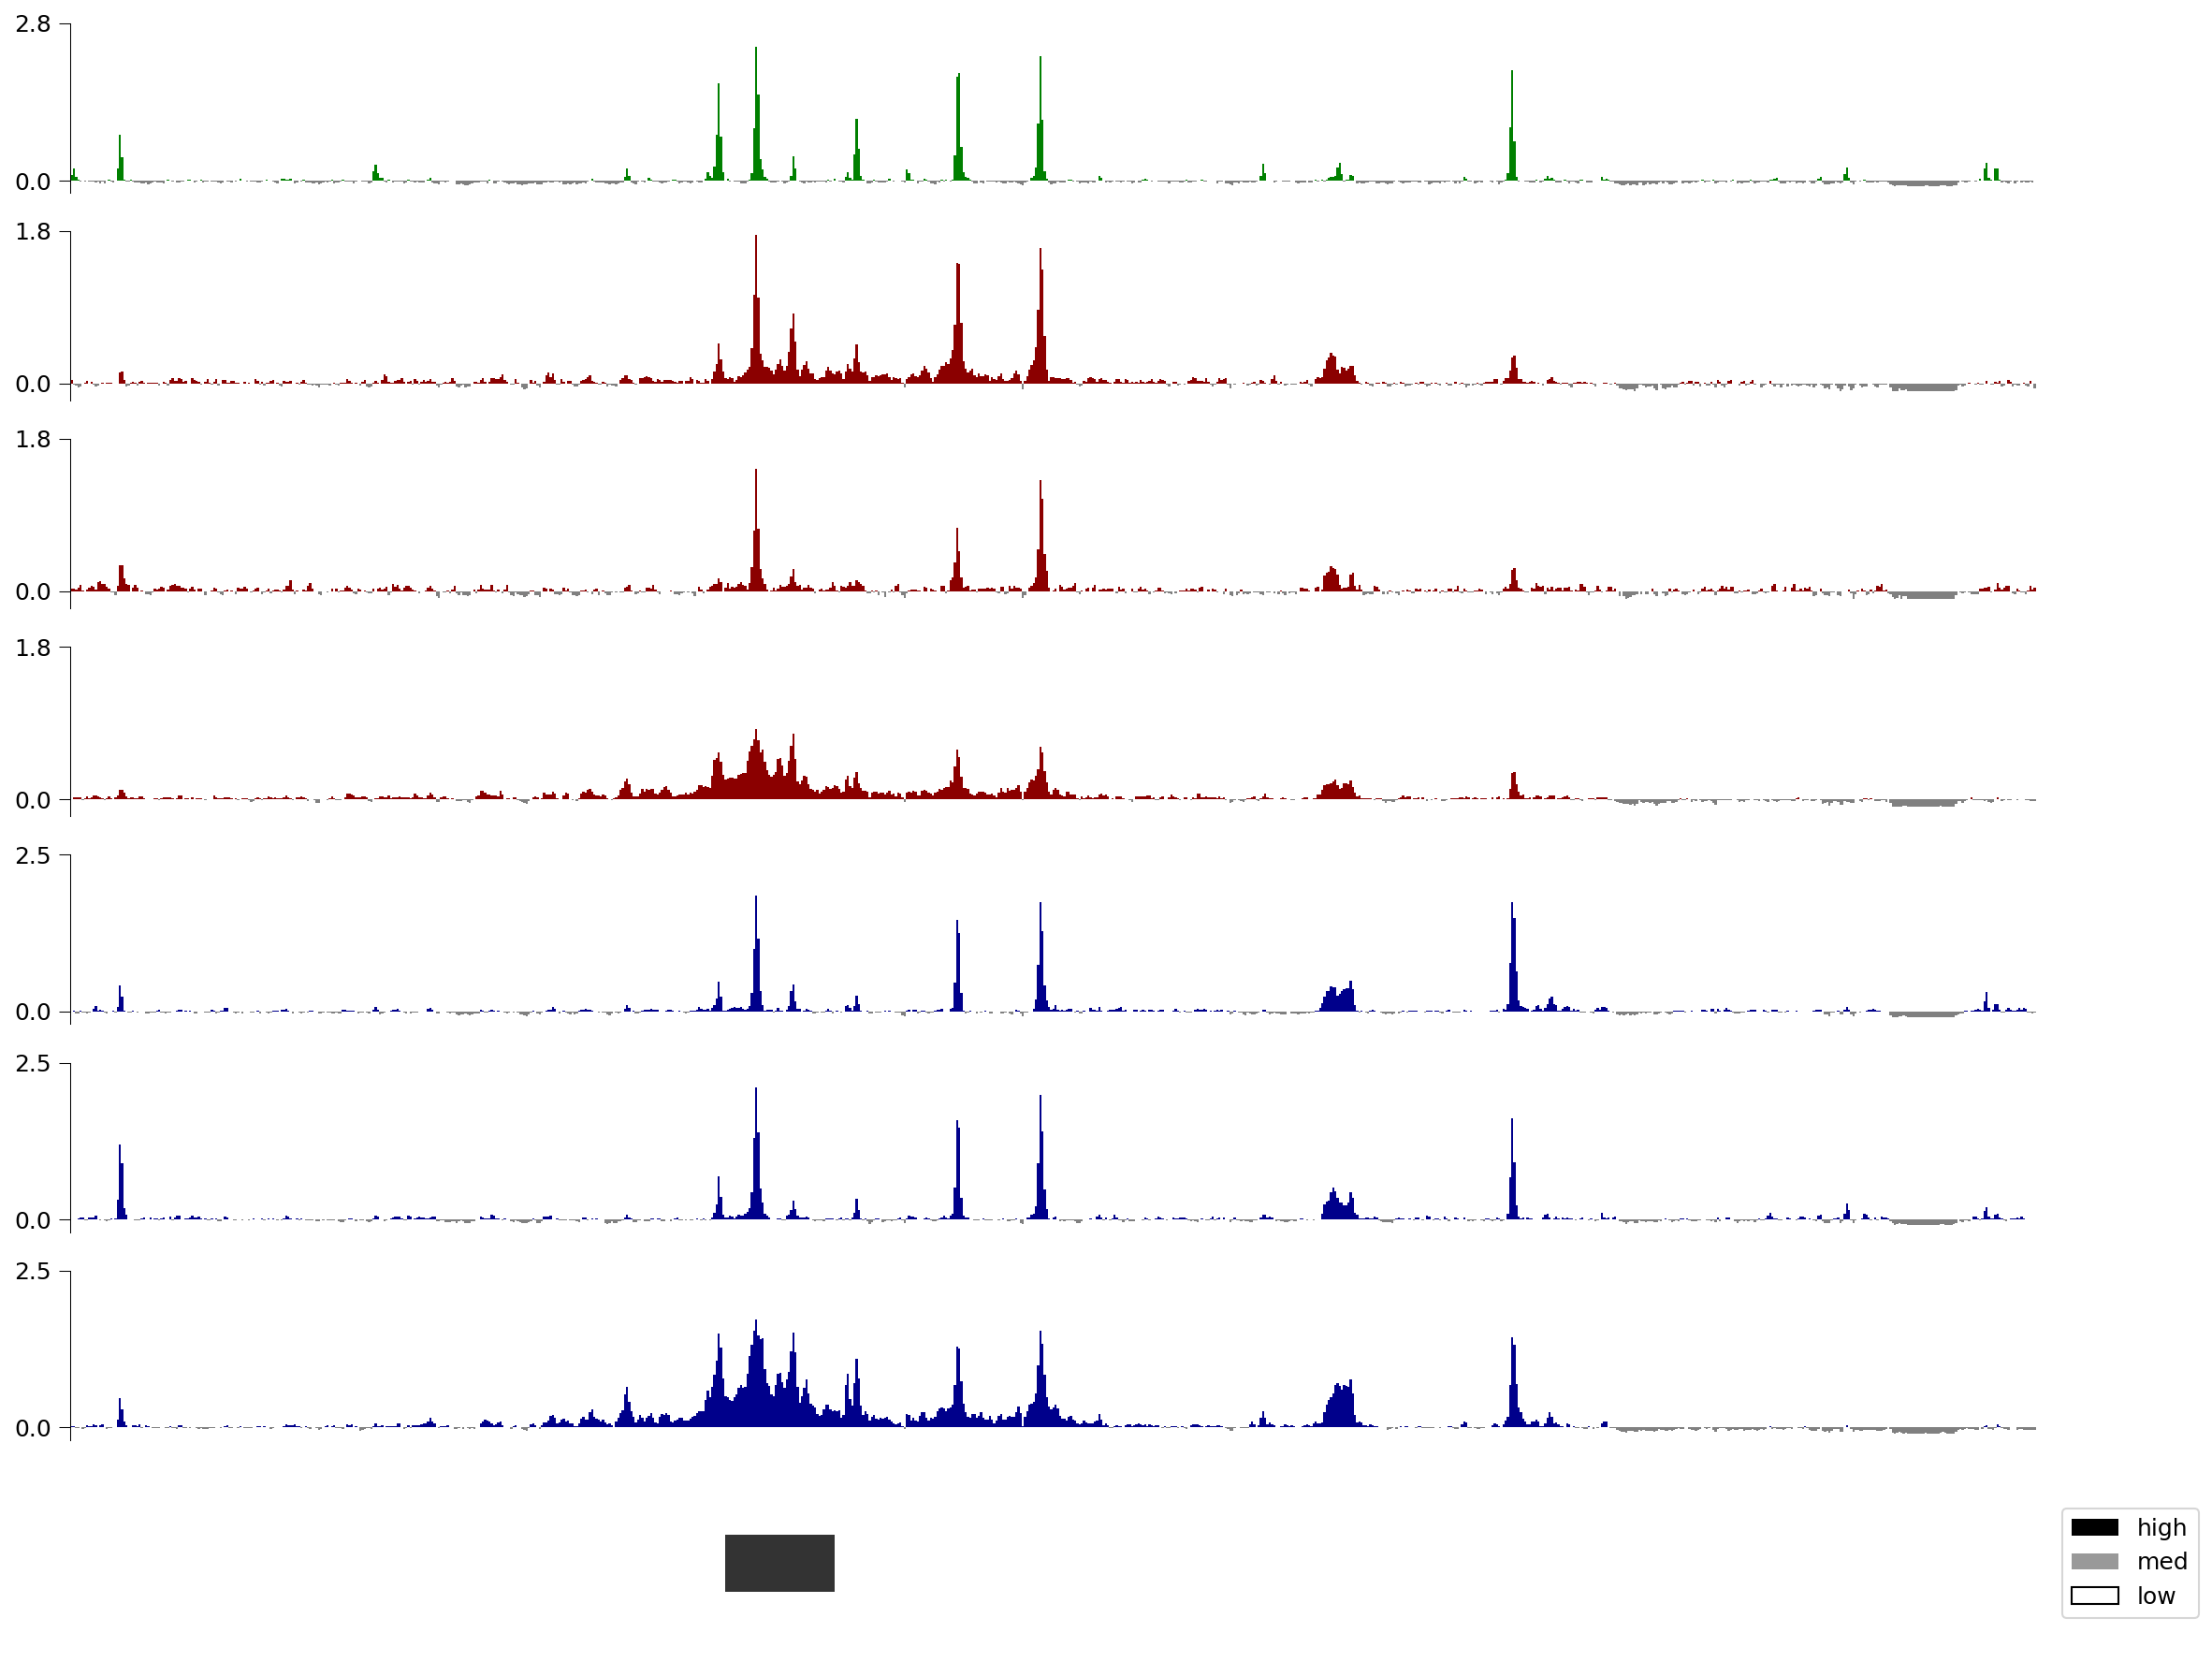

In [7]:
fig_plotter = RegionPlotter(*region)

fig_plotter.add_fill(ctcf_wt, binsize, -0.2, 2.8, 'grey', 'green', height=1, mean_subtract=True)
fig_plotter.add_fill(sor_wt, binsize, -0.2, 1.8, 'grey', 'darkred', height=1, mean_subtract=True)
fig_plotter.add_fill(sor_dnipbl, binsize, -0.2, 1.8, 'grey', 'darkred', height=1, mean_subtract=True)
fig_plotter.add_fill(sor_dwapl, binsize, -0.2, 1.8, 'grey', 'darkred', height=1, mean_subtract=True)
fig_plotter.add_fill(rad21_wt, binsize, -0.2, 2.5, 'grey', 'darkblue', height=1, mean_subtract=True)
fig_plotter.add_fill(rad21_dnipbl, binsize, -0.2, 2.5, 'grey', 'darkblue', height=1, mean_subtract=True)
fig_plotter.add_fill(rad21_dwapl, binsize, -0.2, 2.5, 'grey', 'darkblue', height=1, mean_subtract=True)
fig_plotter.add_df_multi(boundaries_df, hue, new_level_colors, edgecolors=edge_colors, stratify=False, pad=0, height=1)

fig, axes = fig_plotter.plot(figsize=(16, 12), dpi=150, tick_all=False, tick_step=1_000_000)

for i in range(8):
    axes[i, 0].xaxis.set_visible(False) # Remove x axis
    axes[i, 0].spines['bottom'].set_visible(False) # Remove the horizontal line
    
    # Set different ticks based on axis index
    if i == 0:
        axes[i, 0].set_yticks(ticks_ctcf)
    elif 1 <= i <= 3:
        axes[i, 0].set_yticks(ticks_sor)
    elif 4 <= i <= 6:
        axes[i, 0].set_yticks(ticks_rad21)
    
    axes[i, 0].tick_params(axis='y', length=6, width=0.5)
    for spine in axes[i, 0].spines.values():
        spine.set_linewidth(0.5)

axes[7, 0].yaxis.set_visible(False)
axes[7, 0].spines['left'].set_visible(False)

fig.tight_layout()